<a href="https://colab.research.google.com/github/bhakya01/taxis.jpynb/blob/main/taxis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1 Loading the Taxis Dataset using the following code:

In [ ]:
import seaborn as sns
df = sns.load_dataset("taxis")

In [ ]:

df.info()


display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   object        
 13  dropoff_borough  6388 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


2. Handling Missing Values

In [ ]:
# Calculate and display the number of missing values per column
missing_values = df.isnull().sum()
missing_summary = missing_values[missing_values > 0].reset_index()
missing_summary.columns = ['Column', 'Missing Values Count']

print("Columns with missing values:")
display(missing_summary)

Columns with missing values:


,Column,Missing Values Count
0,payment,44
1,pickup_zone,26
2,dropoff_zone,45
3,pickup_borough,26
4,dropoff_borough,45


In [ ]:
# Identify categorical columns with missing values
categorical_cols_with_missing = ['payment', 'pickup_zone', 'dropoff_zone', 'pickup_borough', 'dropoff_borough']

# Impute missing values with the mode of each respective column
for col in categorical_cols_with_missing:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)

# Verify that there are no remaining missing values
print("Missing values left in the entire dataset:")
print(df.isnull().sum())

Missing values left in the entire dataset:
pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64


In [ ]:
# Reload the original dataset to restore missing values
df_cleaned = sns.load_dataset("taxis")

# Define critical columns where missing values cannot be reasonably imputed
critical_cols = ['pickup_zone', 'dropoff_zone', 'pickup_borough', 'dropoff_borough']

# Drop rows where critical columns have missing values
df_cleaned = df_cleaned.dropna(subset=critical_cols)

# For less critical or non-spatial columns like 'payment', we can impute with mode
if df_cleaned['payment'].isnull().any():
    payment_mode = df_cleaned['payment'].mode()[0]
    df_cleaned['payment'] = df_cleaned['payment'].fillna(payment_mode)

# Verify remaining missing values in the cleaned dataset
print("Remaining missing values:")
print(df_cleaned.isnull().sum())
print(f"\nOriginal rows: {len(df)}, Cleaned rows: {len(df_cleaned)}")

Remaining missing values:
pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64

Original rows: 6433, Cleaned rows: 6383


3. Visualizations using Matplotlib/Pandas Plot:
 Line Chart

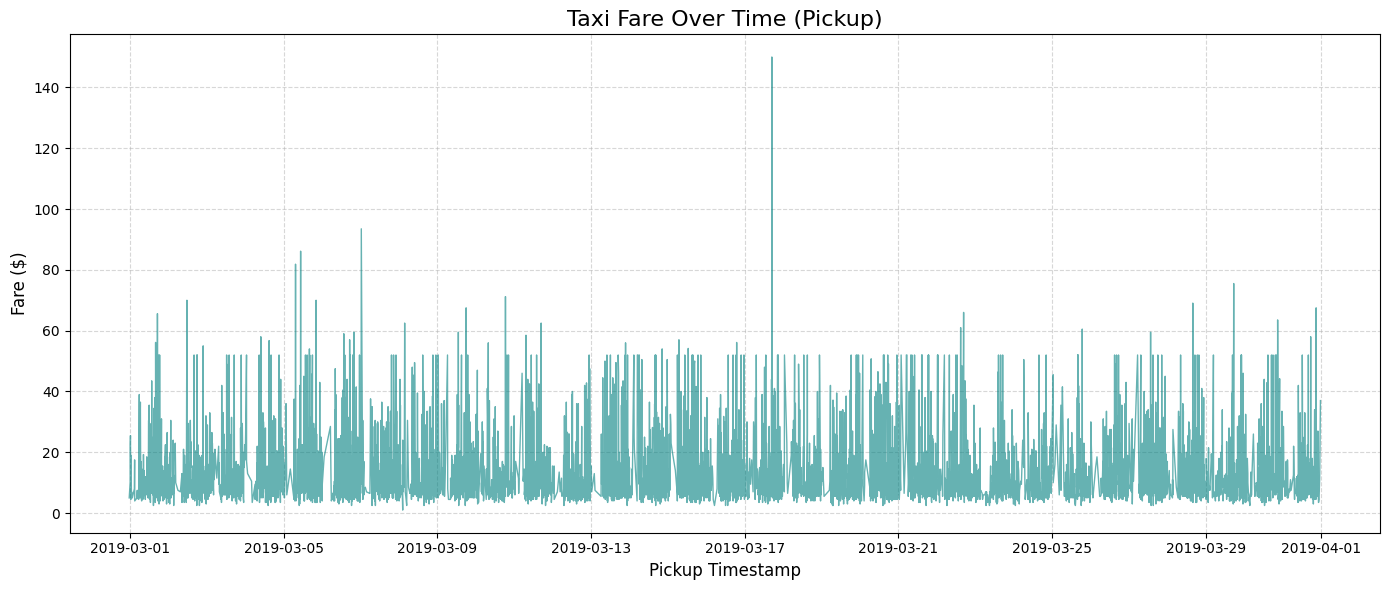

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Ensure the pickup column is in datetime format
df_cleaned['pickup'] = pd.to_datetime(df_cleaned['pickup'])

# Sort the dataframe by pickup time to make sure the line plots sequentially
df_time_plot = df_cleaned.sort_values('pickup')

# Plotting the line chart
plt.figure(figsize=(14, 6))
plt.plot(df_time_plot['pickup'], df_time_plot['fare'], color='teal', alpha=0.6, linewidth=1)
plt.title('Taxi Fare Over Time (Pickup)', fontsize=16)
plt.xlabel('Pickup Timestamp', fontsize=12)
plt.ylabel('Fare ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

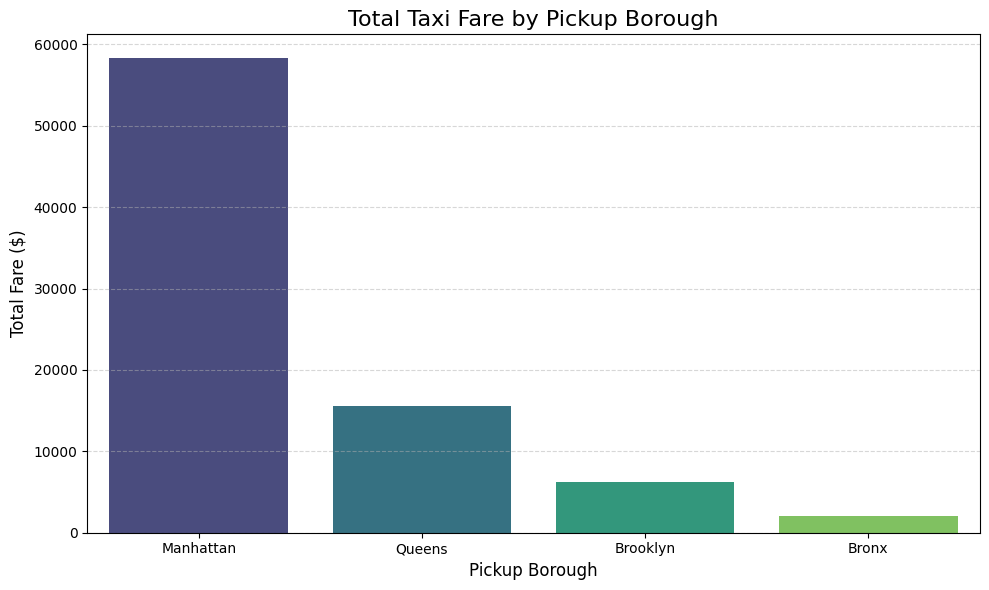

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by pickup_borough and calculate the sum of fares
borough_fares = df_cleaned.groupby('pickup_borough')['fare'].sum().reset_index()

# Sort the values to make the bar chart easier to read
borough_fares = borough_fares.sort_values(by='fare', ascending=False)

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='pickup_borough', y='fare', data=borough_fares, palette='viridis', hue='pickup_borough', legend=False)

# Formatting the plot
plt.title('Total Taxi Fare by Pickup Borough', fontsize=16)
plt.xlabel('Pickup Borough', fontsize=12)
plt.ylabel('Total Fare ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Bar Chart

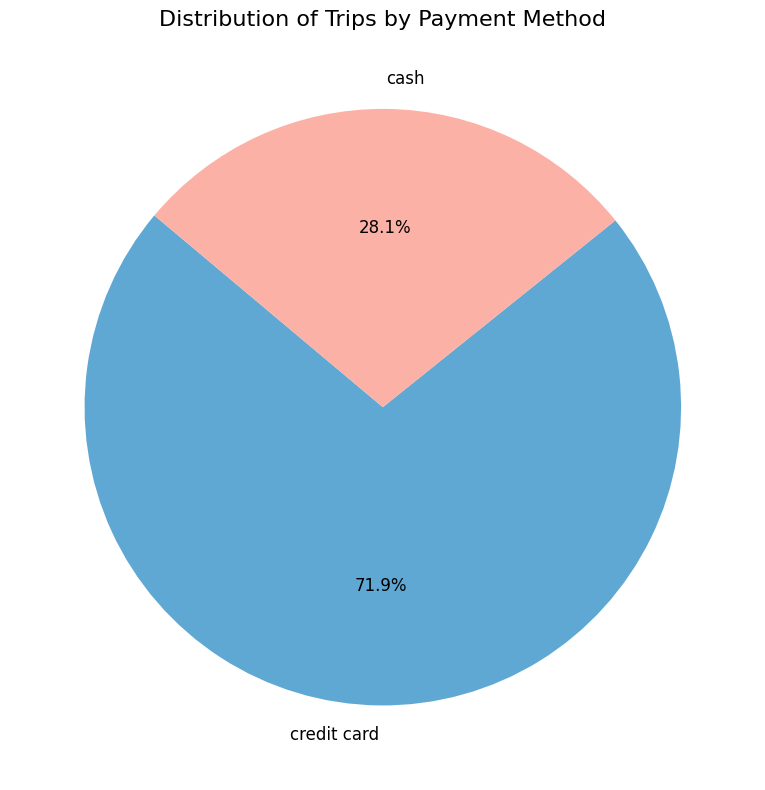

In [ ]:
import matplotlib.pyplot as plt

# Count the number of trips for each payment method
payment_counts = df_cleaned['payment'].value_counts()

# Plotting the pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['#5fa8d3', '#fcb1a6'],
    textprops={'fontsize': 12}
)
plt.title('Distribution of Trips by Payment Method', fontsize=16)
plt.tight_layout()
plt.show()

Pie Chart

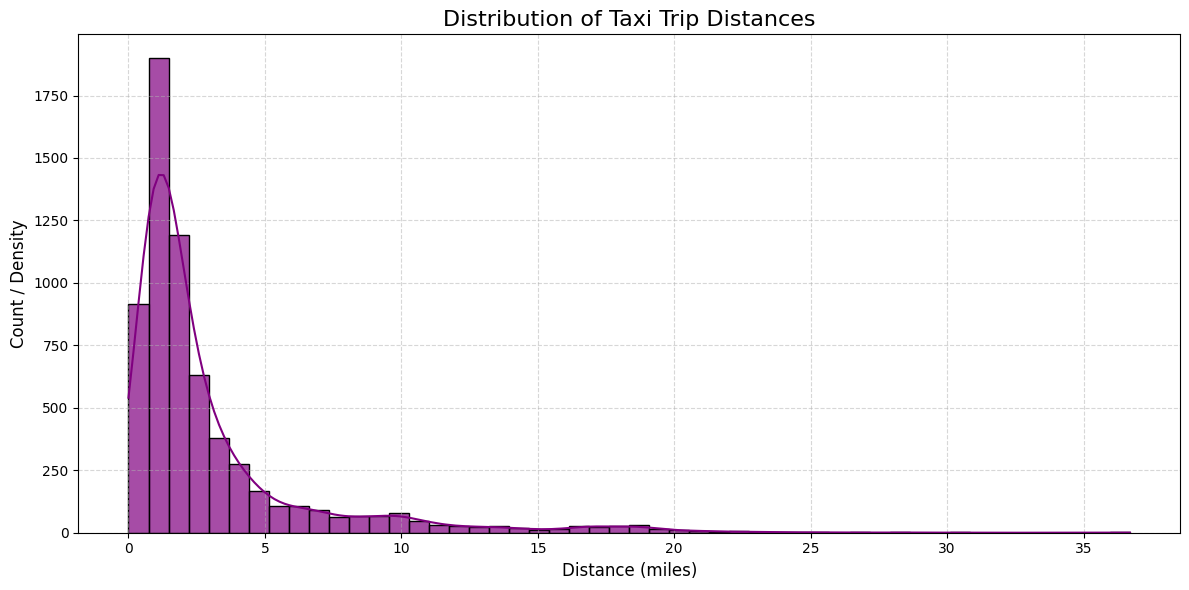

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the distribution of trip distances
plt.figure(figsize=(12, 6))
sns.histplot(df_cleaned['distance'], bins=50, kde=True, color='purple', edgecolor='black', alpha=0.7)

# Formatting the plot
plt.title('Distribution of Taxi Trip Distances', fontsize=16)
plt.xlabel('Distance (miles)', fontsize=12)
plt.ylabel('Count / Density', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Histogram

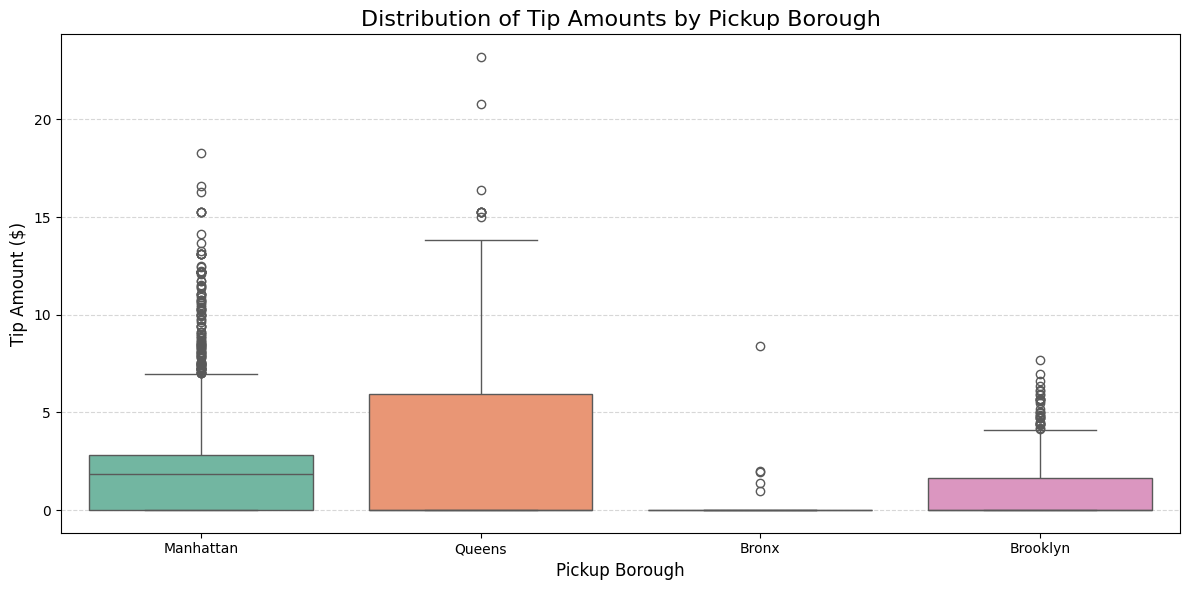

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a box plot showing the distribution of tips by pickup borough
plt.figure(figsize=(12, 6))
sns.boxplot(x='pickup_borough', y='tip', data=df_cleaned, palette='Set2', hue='pickup_borough', legend=False)

# Formatting the plot
plt.title('Distribution of Tip Amounts by Pickup Borough', fontsize=16)
plt.xlabel('Pickup Borough', fontsize=12)
plt.ylabel('Tip Amount ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

 Box Plot

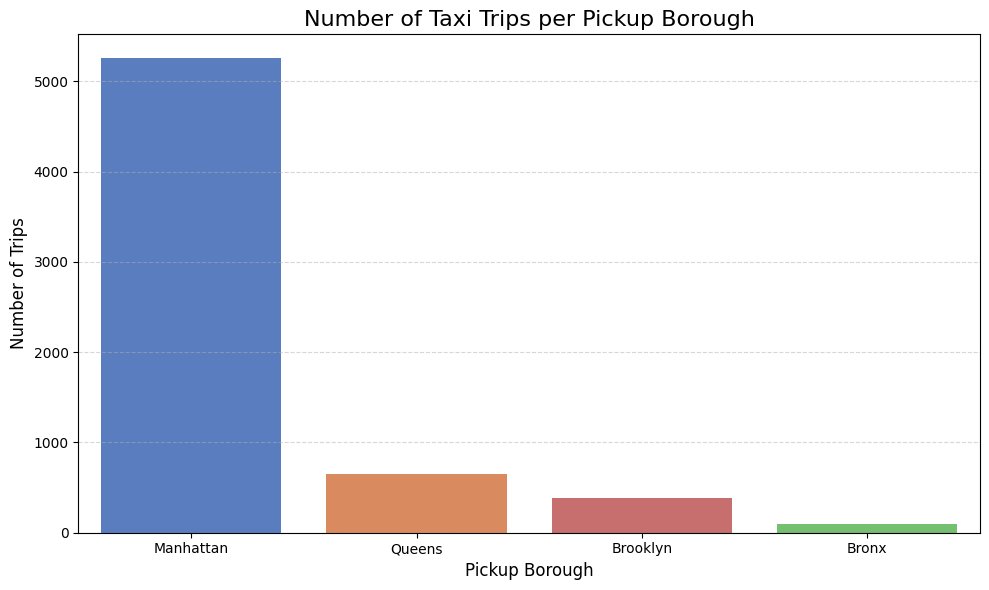

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a count plot of trips per pickup borough
plt.figure(figsize=(10, 6))
sns.countplot(x='pickup_borough', data=df_cleaned, palette='muted', order=df_cleaned['pickup_borough'].value_counts().index, hue='pickup_borough', legend=False)

# Formatting the plot
plt.title('Number of Taxi Trips per Pickup Borough', fontsize=16)
plt.xlabel('Pickup Borough', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

4. Visualizations using Seaborn:
   scatter plot

# New Section

# New Section

# New Section

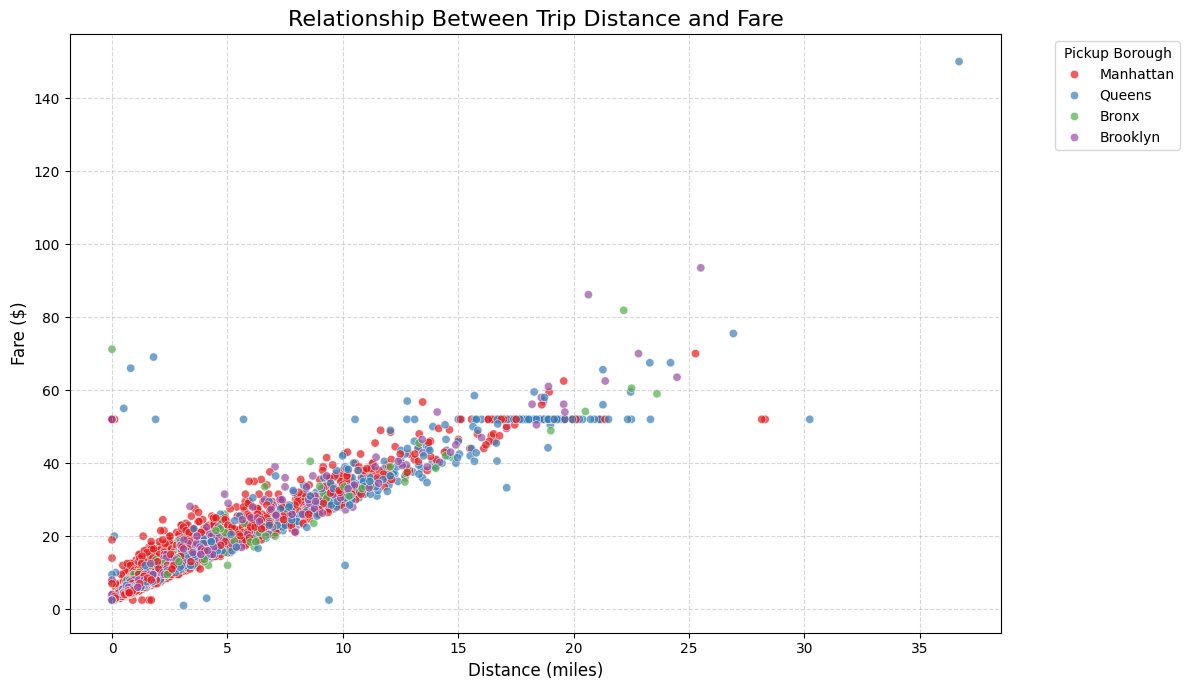

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of distance vs fare
plt.figure(figsize=(12, 7))
sns.scatterplot(
    x='distance',
    y='fare',
    hue='pickup_borough',
    data=df_cleaned,
    palette='Set1',
    alpha=0.7
)

# Formatting the plot
plt.title('Relationship Between Trip Distance and Fare', fontsize=16)
plt.xlabel('Distance (miles)', fontsize=12)
plt.ylabel('Fare ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Pickup Borough', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

 Count Plot


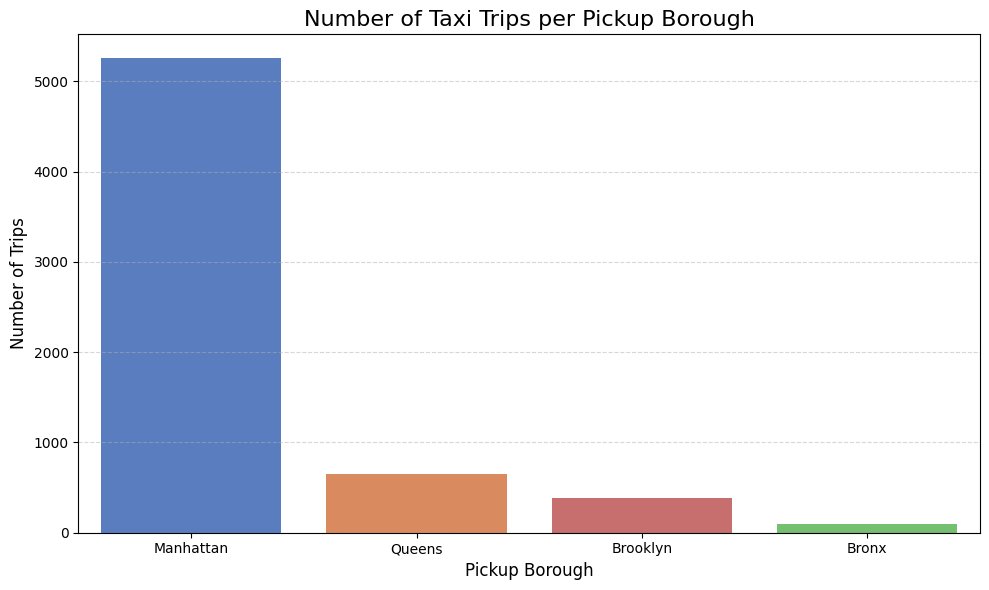

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a count plot for trips per pickup borough
plt.figure(figsize=(10, 6))
sns.countplot(
    x='pickup_borough',
    data=df_cleaned,
    order=df_cleaned['pickup_borough'].value_counts().index,
    palette='muted',
    hue='pickup_borough',
    legend=False
)

# Format the plot
plt.title('Number of Taxi Trips per Pickup Borough', fontsize=16)
plt.xlabel('Pickup Borough', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Heatmap

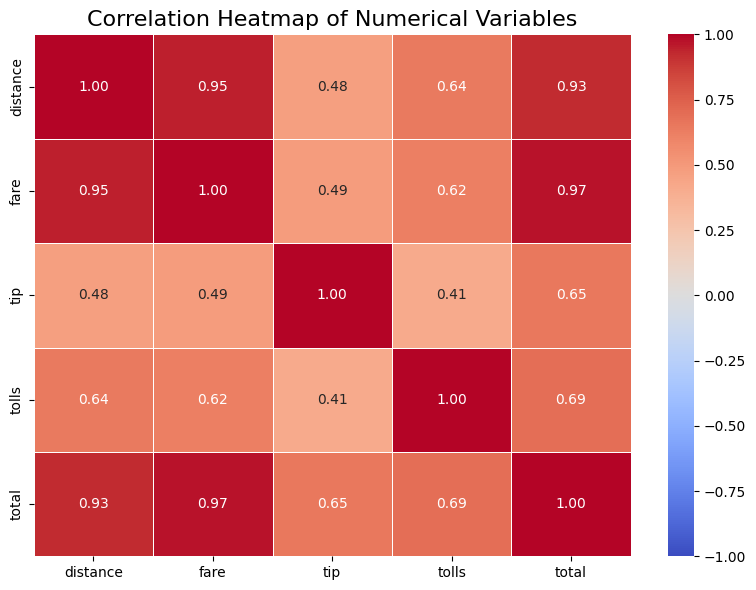

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the specified numerical columns
numerical_cols = ['distance', 'fare', 'tip', 'tolls', 'total']
corr_matrix = df_cleaned[numerical_cols].corr()

# Plot the correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    vmin=-1,
    vmax=1
)

# Formatting the plot
plt.title('Correlation Heatmap of Numerical Variables', fontsize=16)
plt.tight_layout()
plt.show()

Pair Plot

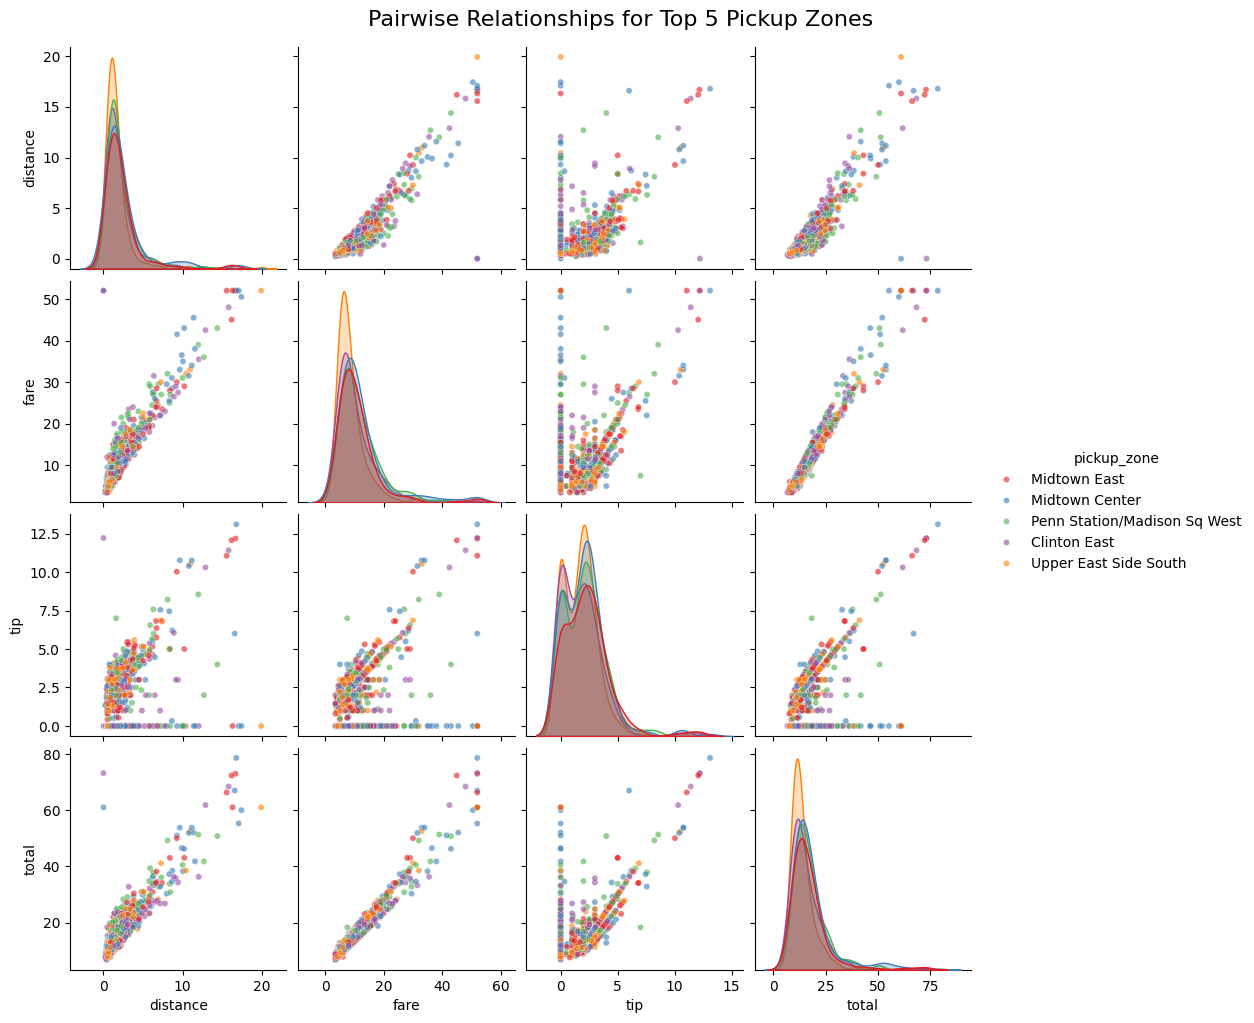

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get the top 5 most frequent pickup zones to keep the plot legible and performant
top_zones = df_cleaned['pickup_zone'].value_counts().nlargest(5).index

# Filter the data for only these top zones
pairplot_data = df_cleaned[df_cleaned['pickup_zone'].isin(top_zones)][['distance', 'fare', 'tip', 'total', 'pickup_zone']]

# Create the pair plot
sns.pairplot(
    pairplot_data,
    vars=['distance', 'fare', 'tip', 'total'],
    hue='pickup_zone',
    palette='Set1',
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 20}
)

plt.suptitle(
    'Pairwise Relationships for Top 5 Pickup Zones',
    y=1.02,
    fontsize=16
)

plt.show()

Violin Plot

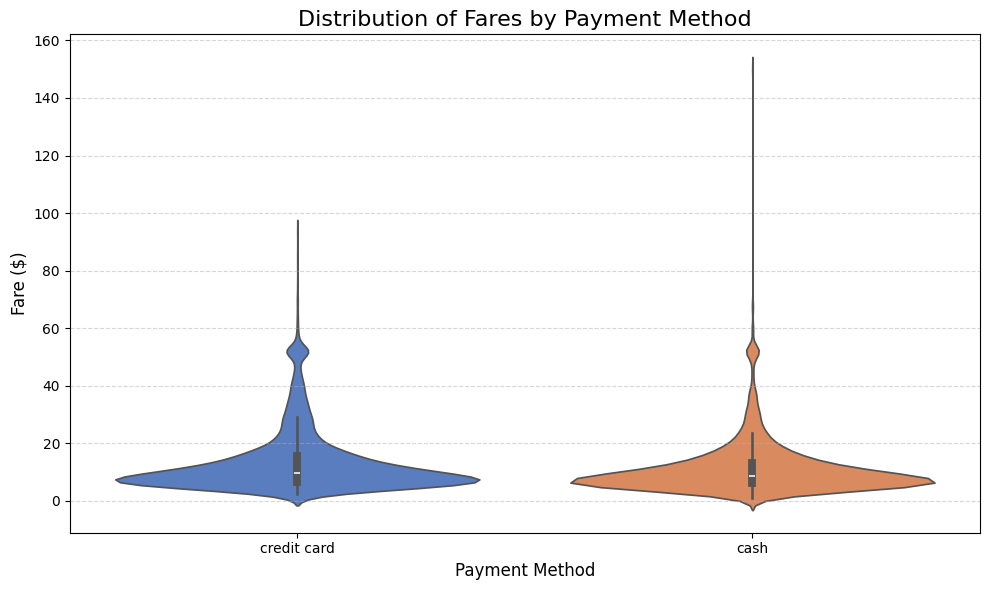

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a violin plot of fare distribution by payment method
plt.figure(figsize=(10, 6))
sns.violinplot(
    x='payment',
    y='fare',
    data=df_cleaned,
    palette='muted',
    hue='payment',
    legend=False
)

# Format the plot
plt.title('Distribution of Fares by Payment Method', fontsize=16)
plt.xlabel('Payment Method', fontsize=12)
plt.ylabel('Fare ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()